# Statistics-Driven Titanic EDA


## Goal

The goal of this notebook is to move beyond basic EDA and study which Titanic survival patterns are strongest, which patterns may be misleading, and which variables are connected to each other.

## Load Data

I am using the feature-engineered Titanic dataset from Week 2. This dataset already includes cleaned missing values and useful features such as family size, title group, age group, and fare group.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("titanic_features.csv")
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck,family_size,title,title_group,age_group,fare_group,is_alone_label
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,2,Mr,Mr,Adult,Low,With family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,Mrs,Mrs,Adult,Very High,With family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,1,Miss,Miss,Adult,Medium,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,2,Mrs,Mrs,Adult,Very High,With family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,1,Mr,Mr,Adult,Medium,Alone


In [3]:
df.shape

(891, 18)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   passengerid     891 non-null    int64  
 1   survived        891 non-null    int64  
 2   pclass          891 non-null    int64  
 3   name            891 non-null    object 
 4   sex             891 non-null    object 
 5   age             891 non-null    float64
 6   sibsp           891 non-null    int64  
 7   parch           891 non-null    int64  
 8   ticket          891 non-null    object 
 9   fare            891 non-null    float64
 10  embarked        891 non-null    object 
 11  deck            891 non-null    object 
 12  family_size     891 non-null    int64  
 13  title           891 non-null    object 
 14  title_group     891 non-null    object 
 15  age_group       891 non-null    object 
 16  fare_group      891 non-null    object 
 17  is_alone_label  891 non-null    obj

In [5]:
df[["age", "fare", "family_size"]].describe()

,age,fare,family_size
count,891.000000,891.000000,891.000000
mean,29.112424,32.204208,1.904602
std,13.304424,49.693429,1.613459
min,0.420000,0.000000,1.000000
25%,21.500000,7.910400,1.000000
50%,26.000000,14.454200,1.000000
75%,36.000000,31.000000,2.000000
max,80.000000,512.329200,11.000000


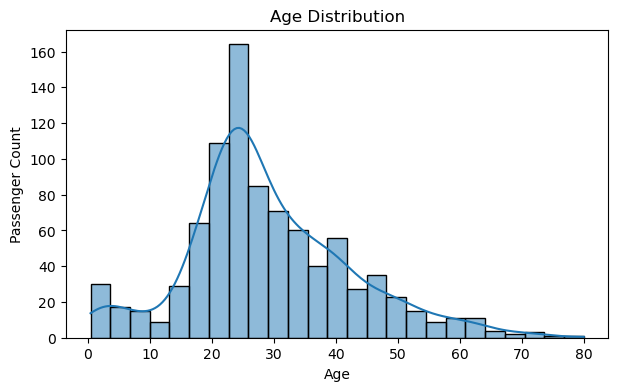

In [6]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", bins=25, kde = True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.show()

Age is spread across children, adults, and seniors.



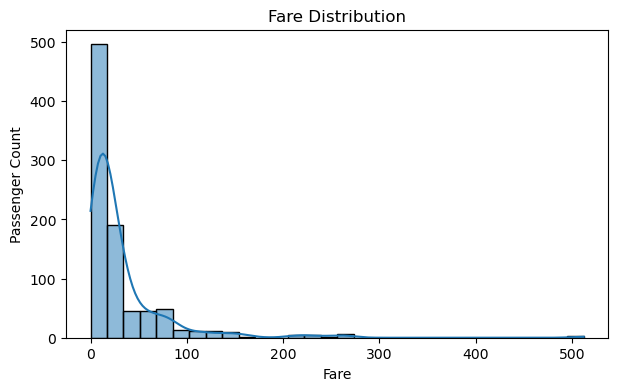

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="fare", bins=30, kde = True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Passenger Count")
plt.show()


Fare is heavily skewed, meaning a few passengers paid much higher fares.

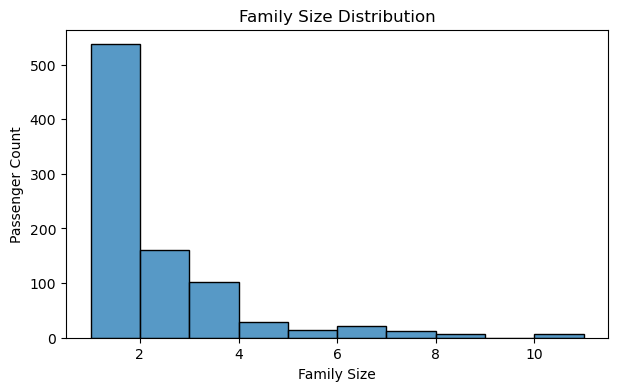

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="family_size", bins=10)
plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Passenger Count")
plt.show()

Family size is mostly small, with many passengers travelling alone or with 1-2 family members.

## Outlier Detection

I will check extreme values in `fare` and `age` using quantiles. This helps me understand whether a few unusual passengers may affect the analysis.

In [9]:
df["fare"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25      7.91040
0.50     14.45420
0.75     31.00000
0.90     77.95830
0.95    112.07915
0.99    249.00622
Name: fare, dtype: float64

In [10]:
df["age"].quantile([0.01, 0.05, 0.5, 0.95, 0.99])

0.01     1.0
0.05     6.0
0.50    26.0
0.95    54.0
0.99    65.0
Name: age, dtype: float64

In [11]:
high_fare = df[df["fare"] > df["fare"].quantile(0.95)]

high_fare[["survived", "pclass", "sex", "age", "fare"]].head(10)

,survived,pclass,sex,age,fare
27,0,1,male,19.0,263.0000
31,1,1,female,35.0,146.5208
88,1,1,female,23.0,263.0000
118,0,1,male,24.0,247.5208
195,1,1,female,58.0,146.5208
215,1,1,female,31.0,113.2750
258,1,1,female,35.0,512.3292
268,1,1,female,58.0,153.4625
269,1,1,female,35.0,135.6333
297,0,1,female,2.0,151.5500


In [12]:
high_fare["pclass"].value_counts()

pclass
1    45
Name: count, dtype: int64

High fare passengers were mostly from higher passenger classes. So fare and class are connected. If high fare passengers survived more, it may be because they were also first-class passengers, not only because of fare itself.

## Survival Rate Helper Function

In [13]:
def survival_rate_by(column):
    return (
        df.groupby(column, observed=True)["survived"]
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )

In [14]:
survival_rate_by("pclass")

pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64

In [15]:
survival_rate_by("sex")

sex
female    74.20
male      18.89
Name: survived, dtype: float64

In [16]:
survival_rate_by("age_group")

age_group
Child     57.97
Teen      41.05
Adult     36.52
Senior    26.92
Name: survived, dtype: float64

In [17]:
survival_rate_by("fare_group")

fare_group
Very High    58.11
High         45.50
Medium       30.36
Low          19.73
Name: survived, dtype: float64

In [18]:
survival_rate_by("title_group")

title_group
Mrs       79.20
Miss      69.78
Master    57.50
Rare      44.44
Mr        15.67
Name: survived, dtype: float64

In [19]:
survival_rate_by("is_alone_label")

is_alone_label
With family    50.56
Alone          30.35
Name: survived, dtype: float64

This helper function makes it easier to compare survival rates across different passenger groups. Since `survived` is coded as 0 or 1, the mean of `survived` gives the survival rate.

## Segmentation Analysis

For segmentation, I compare survival rate together with passenger count so that small groups do not create misleading conclusions.

In [20]:
def survival_summary(group_cols):
    return (
        df.groupby(group_cols, observed=True)
        .agg(
            passengers=("survived", "size"),
            survivors=("survived", "sum"),
            survival_rate_pct=("survived", lambda x: round(x.mean() * 100, 2))
        )
        .reset_index()
        .sort_values("survival_rate_pct", ascending=False)
    )

In [21]:
survival_summary(["sex", "pclass"])

,sex,pclass,passengers,survivors,survival_rate_pct
0,female,1,94,91,96.81
1,female,2,76,70,92.11
2,female,3,144,72,50.00
3,male,1,122,45,36.89
4,male,2,108,17,15.74
5,male,3,347,47,13.54


In [22]:
survival_summary(["sex", "age_group"])


,sex,age_group,passengers,survivors,survival_rate_pct
2,female,Senior,4,4,100.00
3,female,Teen,43,34,79.07
0,female,Adult,235,176,74.89
1,female,Child,32,19,59.38
5,male,Child,37,21,56.76
4,male,Adult,466,80,17.17
6,male,Senior,22,3,13.64
7,male,Teen,52,5,9.62


In [23]:
survival_summary(["pclass", "fare_group"]).sort_values(by = ["pclass"])

,pclass,fare_group,passengers,survivors,survival_rate_pct
2,1,Very High,159,109,68.55
0,1,High,51,27,52.94
1,1,Low,6,0,0.00
3,2,High,70,42,60.00
6,2,Very High,22,12,54.55
5,2,Medium,86,33,38.37
4,2,Low,6,0,0.00
7,3,High,101,32,31.68
9,3,Medium,138,35,25.36
8,3,Low,211,44,20.85


Finding 1: Across every passenger class, females had much higher survival rates than males. First-class females had the strongest survival rate, which suggests that both gender and passenger class were important survival factors.

Finding 2: Some groups have small passenger counts, so their survival rates can be misleading. A small group can produce an extreme percentage, so I should check passenger count before trusting the rate.

Finding 3: Fare and passenger class are connected. First-class passengers usually paid higher fares and also had higher survival rates, so fare may partly reflect passenger class rather than acting as a fully independent factor.

## Visualize segmented survival

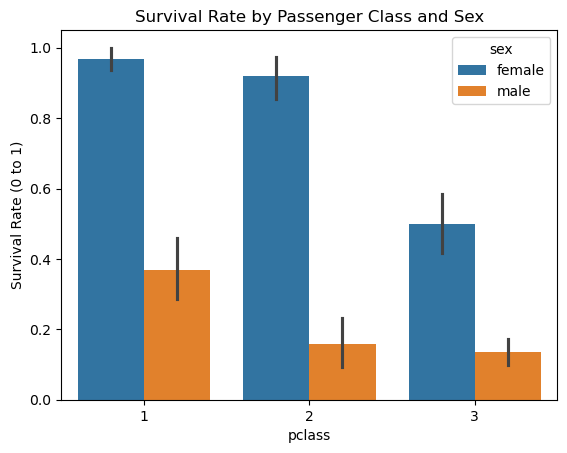

In [24]:
sns.barplot(data=df, x="pclass", y="survived", hue="sex")
plt.title("Survival Rate by Passenger Class and Sex")
plt.ylabel("Survival Rate (0 to 1)")
plt.show()

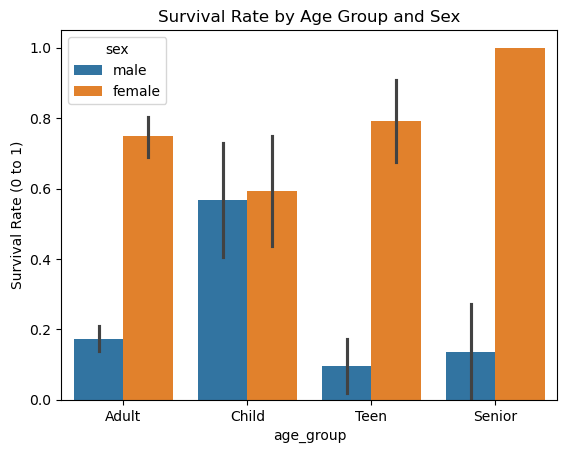

In [25]:
sns.barplot(data=df, x="age_group", y="survived", hue="sex")
plt.title("Survival Rate by Age Group and Sex")
plt.ylabel("Survival Rate (0 to 1)")
plt.show()

A high survival rate is not always a strong finding. I also need to check how many passengers are in that group. Small groups can produce extreme percentages, so sample size matters.

## Day 1 Self-Review

What I learned:
- I learned that outlier detection is important because it reveals unusual values and helps identify relationships between features.

What confused me:
- How quantiles work and how to interpret percentile-based cutoffs.

What I need to improve:
- I need to become better at interpreting statistical outputs, especially quantiles, outliers, and group-wise survival rates.
- I need to avoid making conclusions from percentages alone and always check sample size.


# Day 2: Reliability of Survival Findings

A survival rate is more trustworthy when it is supported by enough passengers. Small groups can produce extreme percentages, so I check passenger count before trusting a finding.

In [26]:
def reliability_table(group_cols, min_passengers=30):
    table = (
        df.groupby(group_cols, observed=True)
        .agg(
            passengers=("survived", "size"),
            survivors=("survived", "sum"),
            survival_rate_pct=("survived", lambda x: round(x.mean() * 100, 2))
        )
        .reset_index()
    )

    table["reliability"] = table["passengers"].apply(
        lambda x: "Reliable" if x >= min_passengers else "Small group"
    )

    return table.sort_values("survival_rate_pct", ascending=False)

In [27]:
reliability_table(["sex", "pclass"])

,sex,pclass,passengers,survivors,survival_rate_pct,reliability
0,female,1,94,91,96.81,Reliable
1,female,2,76,70,92.11,Reliable
2,female,3,144,72,50.00,Reliable
3,male,1,122,45,36.89,Reliable
4,male,2,108,17,15.74,Reliable
5,male,3,347,47,13.54,Reliable


In [28]:
reliability_table(["age_group"])

,age_group,passengers,survivors,survival_rate_pct,reliability
1,Child,69,40,57.97,Reliable
3,Teen,95,39,41.05,Reliable
0,Adult,701,256,36.52,Reliable
2,Senior,26,7,26.92,Small group


In [29]:
reliability_table(["title_group"])

,title_group,passengers,survivors,survival_rate_pct,reliability
3,Mrs,125,99,79.20,Reliable
1,Miss,182,127,69.78,Reliable
0,Master,40,23,57.50,Reliable
4,Rare,27,12,44.44,Small group
2,Mr,517,81,15.67,Reliable


In [30]:
reliability_table(["pclass", "fare_group"])

,pclass,fare_group,passengers,survivors,survival_rate_pct,reliability
2,1,Very High,159,109,68.55,Reliable
3,2,High,70,42,60.00,Reliable
6,2,Very High,22,12,54.55,Small group
0,1,High,51,27,52.94,Reliable
5,2,Medium,86,33,38.37,Reliable
7,3,High,101,32,31.68,Reliable
9,3,Medium,138,35,25.36,Reliable
8,3,Low,211,44,20.85,Reliable
10,3,Very High,41,8,19.51,Reliable
1,1,Low,6,0,0.00,Small group


Finding 1:
The survival pattern by sex and passenger class looks reliable because every sex-class group has more than 30 passengers. First-class females had the highest survival rate at 96.81% with 94 passengers, while third-class males had a much lower survival rate at 13.54% with 347 passengers.

Finding 2:
Some survival rates are less reliable because the group size is small. For example, seniors had only 26 passengers, so their 26.92% survival rate should be interpreted carefully. Rare title groups also had only 27 passengers, so their 44.44% survival rate is less stable.

Finding 3:
The survival pattern connected to sex and passenger class remains strong even after checking passenger count. Female passengers had higher survival rates than male passengers in every class, and all these groups had enough passengers to be considered reliable.

# Weak vs Strong Findings

A finding is strong only if:
1. The survival-rate difference is meaningful.
2. Each compared group has enough passengers.
3. The pattern is not explained by another obvious feature.

In [31]:
reliability_table(["sex", "pclass"])

,sex,pclass,passengers,survivors,survival_rate_pct,reliability
0,female,1,94,91,96.81,Reliable
1,female,2,76,70,92.11,Reliable
2,female,3,144,72,50.00,Reliable
3,male,1,122,45,36.89,Reliable
4,male,2,108,17,15.74,Reliable
5,male,3,347,47,13.54,Reliable


This finding is strong because:
1. The (sex + pclass) survival rates difference is meaningful. For example, the females of pclass1 and males of pclass1 have 96.81 % and 36.89% survival rate respectively, that is a meaningful difference.
2. The reliability column shows that each group has enough passengers, meaning more than 30.
3. This pattern is not explained by any other obvious feature.

In [32]:
reliability_table(["age_group"])

,age_group,passengers,survivors,survival_rate_pct,reliability
1,Child,69,40,57.97,Reliable
3,Teen,95,39,41.05,Reliable
0,Adult,701,256,36.52,Reliable
2,Senior,26,7,26.92,Small group


This finding is weak because:
1. It looks like seniors had lowest survival rate, but the reliability column shows that it is a small group (only 26 passengers in the group).

In [33]:
reliability_table(["pclass", "fare_group"])

,pclass,fare_group,passengers,survivors,survival_rate_pct,reliability
2,1,Very High,159,109,68.55,Reliable
3,2,High,70,42,60.00,Reliable
6,2,Very High,22,12,54.55,Small group
0,1,High,51,27,52.94,Reliable
5,2,Medium,86,33,38.37,Reliable
7,3,High,101,32,31.68,Reliable
9,3,Medium,138,35,25.36,Reliable
8,3,Low,211,44,20.85,Reliable
10,3,Very High,41,8,19.51,Reliable
1,1,Low,6,0,0.00,Small group


This finding is confounded.

1. Higher fare passengers often had higher survival rates, but fare is closely connected to passenger class.
2. First-class passengers paid higher fares and also had better survival rates. However, third-class passengers with very high fares still had only a 19.51% survival rate, so fare alone does not explain survival.
3. Passenger class appears to be the stronger factor.

| Finding | Strong / Weak | Reason |
|---|---|---|
| Females survived more than males across passenger classes | Strong | This pattern is supported by enough passengers in every sex-class group. For example, first-class females had a 96.81% survival rate with 94 passengers, while first-class males had a 36.89% survival rate with 122 passengers. |
| Seniors had the lowest survival rate | Weak | Seniors had only 26 passengers, so their 26.92% survival rate is based on a small group and should be interpreted carefully. |
| Higher fare means higher survival | Confounded | Fare is connected to passenger class. First-class very-high-fare passengers had a 68.55% survival rate, but third-class very-high-fare passengers had only a 19.51% survival rate, so fare alone does not explain survival. |

# Day 3: Correlation Traps

In [34]:
df.groupby("pclass")["fare"].agg(["count", "mean", "median", "min", "max"]).round(2)

,count,mean,median,min,max
pclass,,,,,
1,216,84.15,60.29,0.0,512.33
2,184,20.66,14.25,0.0,73.50
3,491,13.68,8.05,0.0,69.55


Fare is not evenly distributed across passenger classes. First-class passengers generally paid much higher fares than second- and third-class passengers.

In [35]:
df.groupby("pclass")["survived"].agg(
    passengers="size",
    survivors="sum",
    survival_rate_pct=lambda x: round(x.mean() * 100, 2)
)

,passengers,survivors,survival_rate_pct
pclass,,,
1,216,136,62.96
2,184,87,47.28
3,491,119,24.24


In [36]:
df.groupby("fare_group", observed=True)["survived"].agg(
    passengers="size",
    survivors="sum",
    survival_rate_pct=lambda x: round(x.mean() * 100, 2)
).sort_values("survival_rate_pct", ascending=False)

,passengers,survivors,survival_rate_pct
fare_group,,,
Very High,222,129,58.11
High,222,101,45.50
Medium,224,68,30.36
Low,223,44,19.73


In [37]:
df.groupby(["pclass", "fare_group"], observed=True)["survived"].agg(
    passengers="size",
    survivors="sum",
    survival_rate_pct=lambda x: round(x.mean() * 100, 2)
).reset_index().sort_values(["pclass", "survival_rate_pct"], ascending=[True, False])

,pclass,fare_group,passengers,survivors,survival_rate_pct
2,1,Very High,159,109,68.55
0,1,High,51,27,52.94
1,1,Low,6,0,0.00
3,2,High,70,42,60.00
6,2,Very High,22,12,54.55
5,2,Medium,86,33,38.37
4,2,Low,6,0,0.00
7,3,High,101,32,31.68
9,3,Medium,138,35,25.36
8,3,Low,211,44,20.85


Inside the same class, higher fare does not always lead to a higher survival rate. For example, in the class2, the high fare group has higher survival rate(60 %) than very high fare group (54.55%) and in class3, the very high fare group has the least survival rate(19.51%) among all the fare groups.

| Claim | Evidence | Judgment |
|---|---|---|
| Higher fare passengers survived more | It is true for first-class passengers (Very high fare S.R = 68.55%), but not in case of second(Very high fare S.R = 54.55%) and third class passengers(Very high fare S.R = 19.51%). | Partly true |
| First-class passengers paid higher fares | First-class passengers' mean fare is 84.15 which is much higher than the other 2 classes | True |
| Fare alone explains survival | No, pclass actually explains the survival rate because in lower pclasses even on high fare, survival rates are low. | False / Confounded |

Conclusion: Fare appears related to survival, but this relationship is confounded by passenger class. First-class passengers generally paid higher fares and also had higher survival rates. After comparing fare groups within each passenger class, fare alone does not consistently explain survival. Passenger class is likely the stronger explanatory feature.

# Final EDA Report: Titanic Survival Patterns

## 1. Objective

The main objective of this analysis is to understand which passenger features were most strongly related to survival patterns. I focus on passenger class, sex, age group, fare group, and title group, while also checking whether findings are supported by enough passengers. 

## 2. Dataset

In [42]:
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck,family_size,title,title_group,age_group,fare_group,is_alone_label
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,2,Mr,Mr,Adult,Low,With family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,Mrs,Mrs,Adult,Very High,With family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,1,Miss,Miss,Adult,Medium,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,2,Mrs,Mrs,Adult,Very High,With family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,1,Mr,Mr,Adult,Medium,Alone


In [43]:
df.shape

(891, 18)

The dataset contains 891 Titanic passengers. The target column is `survived`, where 1 means survived and 0 means did not survive. The analysis uses engineered features such as `age_group`, `fare_group`, `title_group`, and `family_size` along with original features like `sex` and `pclass`.

## 3. Key Findings

### Finding 1: Sex and passenger class were the strongest survival signals
First-class females had a 96.81% survival rate with 94 passengers, while third-class males had a 13.54% survival rate with 347 passengers. This shows a large and reliable survival difference across sex and class.

### Finding 2: Children had higher survival, but age findings need care
Children had a 57.97% survival rate with 69 passengers, while seniors had a 26.92% survival rate with only 26 passengers. The child finding is more reliable than the senior finding because the senior group is small.

### Finding 3: Fare was related to survival, but it was confounded by class
Very-high-fare passengers had a 58.11% survival rate overall, but third-class very-high-fare passengers had only a 19.51% survival rate. This suggests fare alone does not explain survival; passenger class is likely the stronger factor.

## 4. Visual Evidence

In [50]:
import matplotlib.ticker as mtick

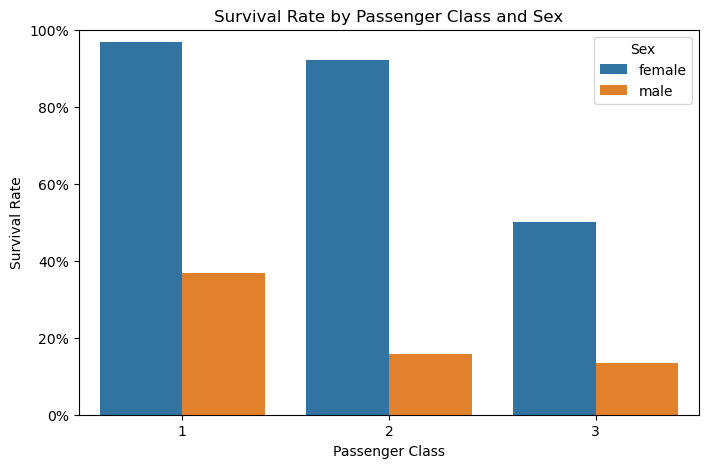

In [51]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, 1)
plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.legend(title="Sex")
plt.show()

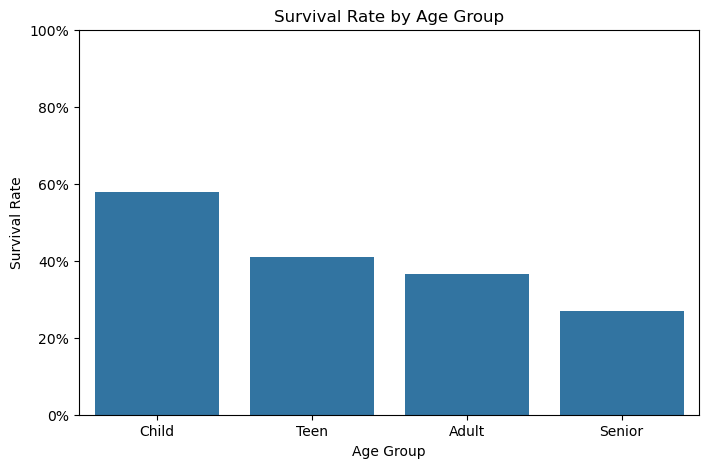

In [52]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df,
    x="age_group",
    y="survived",
    order=["Child", "Teen", "Adult", "Senior"],
    errorbar=None
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, 1)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

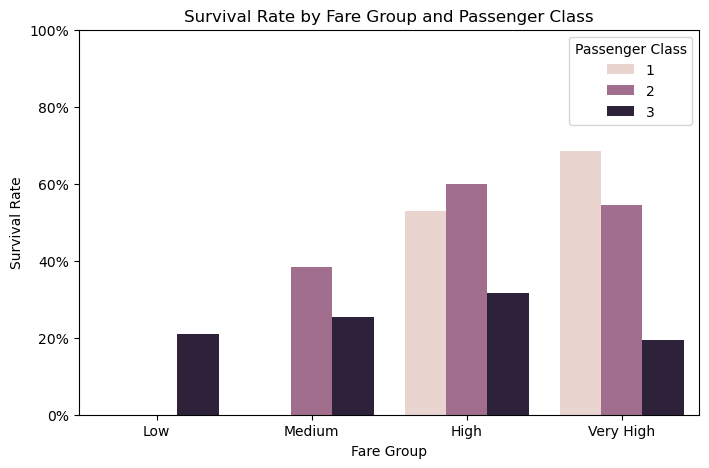

In [53]:
fare_order = ["Low", "Medium", "High", "Very High"]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df,
    x="fare_group",
    y="survived",
    hue="pclass",
    order=fare_order,
    errorbar=None
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, 1)
plt.title("Survival Rate by Fare Group and Passenger Class")
plt.xlabel("Fare Group")
plt.ylabel("Survival Rate")
plt.legend(title="Passenger Class")
plt.show()

## 5. Reliability Check

The sex and passenger class finding is strong because every sex-class group has more than 30 passengers and the survival differences are large. The senior age-group finding is weaker because it has only 26 passengers. The fare finding is confounded because fare is closely connected to passenger class.

## 6. Conclusion

The strongest survival pattern in this analysis is the combined effect of sex and passenger class. Female passengers survived at much higher rates than male passengers across every passenger class, and first-class passengers had better survival outcomes than lower-class passengers. Age and fare also showed patterns, but they required caution because senior passengers formed a small group and fare was strongly connected to passenger class.